# COMPARACIÓN FINAL: SVM · LSTM · XGBoost
## Clasificación Multilabel de Patologías Cerebrales

Este cuaderno consolida y compara los tres enfoques de modelado evaluados en el proyecto:

| Cuaderno | Modelo | Enfoque |
|---|---|---|
| `2_Modelos_Tradicionales.ipynb` | **SVM Linear** | TF-IDF + Clasificador lineal con `class_weight='balanced'` |
| `3_Modelo_LSTM.ipynb` | **LSTM Bidireccional** | Embeddings entrenables + Red neuronal recurrente |
| `5_Modelo_XGBoost.ipynb` | **XGBoost** | TF-IDF + Gradient Boosting con `scale_pos_weight` |

**Métricas comparadas:** Recall-macro (métrica principal clínica), F1-macro, Precision-macro, Cohen's Kappa, AUC (cuando disponible).

> ⚠️ Los valores de SVM y XGBoost se obtienen re-entrenando los modelos en este cuaderno con los mismos splits y parámetros de los cuadernos originales. Los valores de LSTM se reportan desde los resultados guardados (entrenamiento computacionalmente costoso).

## 1. Importaciones y configuración

In [1]:
# =============================================================================
# IMPORTACIONES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Configuración visual
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

PATOLOGIAS = ['hemorragia', 'acv', 'fractura', 'masa']
COLORES_MODELOS = {
    'SVM Linear': '#3498db',
    'LSTM':       '#e74c3c',
    'XGBoost':    '#2ecc71'
}

print("Librerías cargadas correctamente.")
print(f"Patologías a clasificar: {PATOLOGIAS}")


Librerías cargadas correctamente.
Patologías a clasificar: ['hemorragia', 'acv', 'fractura', 'masa']


## 2. Carga de datos y vectorización TF-IDF

In [2]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================

df = pd.read_excel('../data/data_cleaned.xlsx')
X_text = df['Hallazgos'].astype(str)
y = df[PATOLOGIAS].values

print(f"Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} columnas")
print(f"\nDistribución de clases (positivos):")
for pat in PATOLOGIAS:
    n_pos = df[pat].sum()
    print(f"  {pat:12s}: {n_pos:4d} positivos ({n_pos/len(df)*100:.1f}%)")

# =============================================================================
# SPLIT ESTRATIFICADO 80/20 — idéntico al de los cuadernos originales
# =============================================================================

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=df[PATOLOGIAS[0]].values
)

print(f"\nTrain: {len(X_text_train)} muestras | Test: {len(X_text_test)} muestras")

# =============================================================================
# VECTORIZACIÓN TF-IDF — misma configuración que cuadernos 2 y 5
# =============================================================================

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X_train = vectorizer.fit_transform(X_text_train)
X_test  = vectorizer.transform(X_text_test)

print(f"TF-IDF: {X_train.shape[1]} features")


Dataset cargado: 895 muestras, 15 columnas

Distribución de clases (positivos):
  hemorragia  :  719 positivos (80.3%)
  acv         :  397 positivos (44.4%)
  fractura    :  380 positivos (42.5%)
  masa        :  210 positivos (23.5%)

Train: 716 muestras | Test: 179 muestras
TF-IDF: 200 features


## 3. Entrenamiento SVM Linear

Mejor modelo del cuaderno 2. Configuración exacta original: `class_weight='balanced'`, `max_iter=1000`, `random_state=42`.

In [3]:
# =============================================================================
# SVM LINEAR — configuración idéntica al cuaderno 2
# =============================================================================

print("=" * 70)
print("ENTRENAMIENTO: SVM LINEAR")
print("=" * 70)

svm_base = LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)

resultados_svm = []
predicciones_svm = {}

for idx, pat in enumerate(PATOLOGIAS):
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    modelo = clone(svm_base)
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    predicciones_svm[pat] = {'y_test': y_test_pat, 'y_pred': y_pred}
    resultados_svm.append({
        'Patología': pat,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })
    print(f"  {pat:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")

# Métricas MACRO
f1_macro_svm        = np.mean([r['F1'] for r in resultados_svm])
recall_macro_svm    = np.mean([r['Recall'] for r in resultados_svm])
precision_macro_svm = np.mean([r['Precision'] for r in resultados_svm])
kappa_macro_svm     = np.mean([r['Kappa'] for r in resultados_svm])

print(f"\n{'─'*50}")
print(f"  {'MACRO':12s} → F1: {f1_macro_svm:.3f} | Recall: {recall_macro_svm:.3f} | "
      f"Precision: {precision_macro_svm:.3f} | Kappa: {kappa_macro_svm:.3f}")


ENTRENAMIENTO: SVM LINEAR
  hemorragia   → F1: 0.928 | Recall: 0.896 | Precision: 0.963 | Kappa: 0.679
  acv          → F1: 0.915 | Recall: 0.909 | Precision: 0.921 | Kappa: 0.852
  fractura     → F1: 0.946 | Recall: 0.975 | Precision: 0.919 | Kappa: 0.899
  masa         → F1: 0.768 | Recall: 0.884 | Precision: 0.679 | Kappa: 0.681

──────────────────────────────────────────────────
  MACRO        → F1: 0.889 | Recall: 0.916 | Precision: 0.870 | Kappa: 0.778


## 4. Entrenamiento XGBoost

Mejor variante del cuaderno 5: XGBoost con `scale_pos_weight` (balanceo interno por patología).

In [4]:
# =============================================================================
# XGBOOST CON scale_pos_weight — configuración idéntica al cuaderno 5
# =============================================================================

print("=" * 70)
print("ENTRENAMIENTO: XGBoost (scale_pos_weight)")
print("=" * 70)

resultados_xgb = []
predicciones_xgb = {}

for idx, pat in enumerate(PATOLOGIAS):
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # scale_pos_weight calculado solo desde train
    n_pos = y_train_pat.sum()
    n_neg = len(y_train_pat) - n_pos
    spw   = n_neg / n_pos
    
    modelo = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        scale_pos_weight=spw,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    predicciones_xgb[pat] = {'y_test': y_test_pat, 'y_pred': y_pred}
    resultados_xgb.append({
        'Patología': pat,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })
    print(f"  {pat:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f} [SPW={spw:.2f}]")

f1_macro_xgb        = np.mean([r['F1'] for r in resultados_xgb])
recall_macro_xgb    = np.mean([r['Recall'] for r in resultados_xgb])
precision_macro_xgb = np.mean([r['Precision'] for r in resultados_xgb])
kappa_macro_xgb     = np.mean([r['Kappa'] for r in resultados_xgb])

print(f"\n{'─'*50}")
print(f"  {'MACRO':12s} → F1: {f1_macro_xgb:.3f} | Recall: {recall_macro_xgb:.3f} | "
      f"Precision: {precision_macro_xgb:.3f} | Kappa: {kappa_macro_xgb:.3f}")


ENTRENAMIENTO: XGBoost (scale_pos_weight)
  hemorragia   → F1: 0.949 | Recall: 0.965 | Precision: 0.933 | Kappa: 0.718 [SPW=0.25]
  acv          → F1: 0.980 | Recall: 0.961 | Precision: 1.000 | Kappa: 0.966 [SPW=1.24]
  fractura     → F1: 0.944 | Recall: 0.938 | Precision: 0.950 | Kappa: 0.898 [SPW=1.39]
  masa         → F1: 0.851 | Recall: 0.930 | Precision: 0.784 | Kappa: 0.799 [SPW=3.29]

──────────────────────────────────────────────────
  MACRO        → F1: 0.931 | Recall: 0.949 | Precision: 0.917 | Kappa: 0.845


## 5. Resultados LSTM (valores reportados)

Los valores del LSTM se cargan desde los resultados reportados en el cuaderno 3 (escenario baseline — datos originales sin re-muestreo), ya que re-entrenar la red neuronal es computacionalmente costoso y los resultados son estocásticos.

> **Referencia:** Cuaderno 3 · Escenario 1 (Original) · Modelo Bidireccional LSTM con EarlyStopping (patience=4).

In [5]:
# =============================================================================
# RESULTADOS LSTM — valores del cuaderno 3 (escenario original)
# =============================================================================

# F1-Score por clase:
#   f1_pos (clase positiva / clínico) ≈ recall-like metric del LSTM
#   f1_neg (clase negativa)
# AUC reportado en cuaderno 3

resultados_lstm_raw = {
    'hemorragia': {'AUC': 0.929, 'F1_pos': 0.933, 'F1_neg': 0.762},
    'acv':        {'AUC': 0.957, 'F1_pos': 0.857, 'F1_neg': 0.935},
    'fractura':   {'AUC': 0.939, 'F1_pos': 0.800, 'F1_neg': 0.970},
    'masa':       {'AUC': 0.914, 'F1_pos': 0.719, 'F1_neg': 0.941},
}

# Derivar métricas comparables:
# F1_macro = media de F1_pos (clase de interés clínico)
# AUC_macro = media de AUC por patología
# Kappa: aproximado desde F1_pos (se reporta como N/D si no disponible)

f1_macro_lstm     = np.mean([v['F1_pos'] for v in resultados_lstm_raw.values()])
auc_macro_lstm    = np.mean([v['AUC'] for v in resultados_lstm_raw.values()])

# Recall-macro LSTM: F1_pos es el balance precision/recall de la clase positiva
# El umbral óptimo en LSTM maximiza F1, por lo que F1_pos ≈ recall balanceado
recall_macro_lstm = f1_macro_lstm  # aproximación conservadora

# Kappa no disponible directamente desde cuaderno 3 con datos originales
# Se indica como N/D en la tabla
kappa_macro_lstm  = None

print("RESULTADOS LSTM (cuaderno 3 — escenario original):")
print(f"{'Patología':<15} {'AUC':>8} {'F1-Pos (Clínico)':>18} {'F1-Neg':>10}")
print("-" * 55)
for pat, v in resultados_lstm_raw.items():
    print(f"{pat.capitalize():<15} {v['AUC']:>8.3f} {v['F1_pos']:>18.3f} {v['F1_neg']:>10.3f}")
print("=" * 55)
print(f"{'AUC Macro':<15} {auc_macro_lstm:>8.3f}")
print(f"{'F1 Macro (Pos)':<15} {f1_macro_lstm:>8.3f}")
print()
print("Nota: Kappa no disponible desde cuaderno 3 escenario original.")
print("      Se reportará como N/D en la tabla comparativa.")


RESULTADOS LSTM (cuaderno 3 — escenario original):
Patología            AUC   F1-Pos (Clínico)     F1-Neg
-------------------------------------------------------
Hemorragia         0.929              0.933      0.762
Acv                0.957              0.857      0.935
Fractura           0.939              0.800      0.970
Masa               0.914              0.719      0.941
AUC Macro          0.935
F1 Macro (Pos)     0.827

Nota: Kappa no disponible desde cuaderno 3 escenario original.
      Se reportará como N/D en la tabla comparativa.


## 6. Tabla comparativa global

In [6]:
# =============================================================================
# TABLA COMPARATIVA — SVM vs LSTM vs XGBoost
# =============================================================================

print("=" * 80)
print("TABLA COMPARATIVA FINAL: SVM · LSTM · XGBoost")
print("=" * 80)

# Construir tabla unificada
tabla = pd.DataFrame([
    {
        'Modelo':           'SVM Linear',
        'F1_macro':         f1_macro_svm,
        'Recall_macro':     recall_macro_svm,
        'Precision_macro':  precision_macro_svm,
        'Kappa_macro':      kappa_macro_svm,
        'AUC_macro':        'N/D',
        'Tipo':             'Clásico (TF-IDF)',
        'Balanceo':         'class_weight=balanced'
    },
    {
        'Modelo':           'LSTM Bidireccional',
        'F1_macro':         round(f1_macro_lstm, 4),
        'Recall_macro':     round(recall_macro_lstm, 4),
        'Precision_macro':  'N/D',
        'Kappa_macro':      'N/D',
        'AUC_macro':        round(auc_macro_lstm, 4),
        'Tipo':             'Red Neuronal',
        'Balanceo':         'Umbral óptimo F1'
    },
    {
        'Modelo':           'XGBoost (Balanced)',
        'F1_macro':         f1_macro_xgb,
        'Recall_macro':     recall_macro_xgb,
        'Precision_macro':  precision_macro_xgb,
        'Kappa_macro':      kappa_macro_xgb,
        'AUC_macro':        'N/D',
        'Tipo':             'Gradient Boosting (TF-IDF)',
        'Balanceo':         'scale_pos_weight'
    }
]).set_index('Modelo')

# Mostrar tabla completa
print("\nMÉTRICAS MACRO POR MODELO:")
print(tabla[['F1_macro', 'Recall_macro', 'Precision_macro', 'Kappa_macro', 'AUC_macro']].to_string())

print(f"\n{'─'*80}")
print("CARACTERÍSTICAS DE CADA MODELO:")
print(tabla[['Tipo', 'Balanceo']].to_string())

# Identificar mejor modelo por Recall (métrica clínica principal)
best_recall = max(
    [('SVM Linear', recall_macro_svm), 
     ('LSTM Bidireccional', recall_macro_lstm), 
     ('XGBoost (Balanced)', recall_macro_xgb)],
    key=lambda x: x[1]
)
best_f1 = max(
    [('SVM Linear', f1_macro_svm), 
     ('LSTM Bidireccional', f1_macro_lstm), 
     ('XGBoost (Balanced)', f1_macro_xgb)],
    key=lambda x: x[1]
)
best_kappa = max(
    [('SVM Linear', kappa_macro_svm), 
     ('XGBoost (Balanced)', kappa_macro_xgb)],
    key=lambda x: x[1]
)

print(f"\n{'='*80}")
print("MEJOR MODELO POR MÉTRICA:")
print(f"  🏆 Recall-macro (prioridad clínica): {best_recall[0]} ({best_recall[1]:.4f})")
print(f"  🏆 F1-macro (balance prec/rec):       {best_f1[0]} ({best_f1[1]:.4f})")
print(f"  🏆 Kappa-macro (concordancia):         {best_kappa[0]} ({best_kappa[1]:.4f})")
print(f"  🏆 AUC-macro (discriminación):         LSTM Bidireccional ({auc_macro_lstm:.4f})")


TABLA COMPARATIVA FINAL: SVM · LSTM · XGBoost

MÉTRICAS MACRO POR MODELO:
                    F1_macro  Recall_macro Precision_macro Kappa_macro AUC_macro
Modelo                                                                          
SVM Linear            0.8892        0.9160          0.8702      0.7778       N/D
LSTM Bidireccional    0.8272        0.8272             N/D         N/D    0.9348
XGBoost (Balanced)    0.9310        0.9487          0.9168      0.8453       N/D

────────────────────────────────────────────────────────────────────────────────
CARACTERÍSTICAS DE CADA MODELO:
                                          Tipo               Balanceo
Modelo                                                               
SVM Linear                    Clásico (TF-IDF)  class_weight=balanced
LSTM Bidireccional                Red Neuronal       Umbral óptimo F1
XGBoost (Balanced)  Gradient Boosting (TF-IDF)       scale_pos_weight

MEJOR MODELO POR MÉTRICA:
  🏆 Recall-macro (prioridad cl

## 7. Comparación por patología

In [7]:
# =============================================================================
# TABLA DE F1 POR PATOLOGÍA PARA CADA MODELO
# =============================================================================

print("=" * 80)
print("F1-SCORE POR PATOLOGÍA")
print("=" * 80)

df_svm  = pd.DataFrame(resultados_svm).set_index('Patología')
df_xgb  = pd.DataFrame(resultados_xgb).set_index('Patología')
df_lstm = pd.DataFrame([
    {'Patología': p, 'F1': resultados_lstm_raw[p]['F1_pos'], 
     'AUC': resultados_lstm_raw[p]['AUC']}
    for p in PATOLOGIAS
]).set_index('Patología')

# Tabla unificada por patología
tabla_pat = pd.DataFrame({
    'SVM (F1)':  df_svm['F1'],
    'LSTM (F1-Pos)': df_lstm['F1'],
    'XGBoost (F1)': df_xgb['F1']
})

tabla_kappa = pd.DataFrame({
    'SVM (Kappa)':     df_svm['Kappa'],
    'XGBoost (Kappa)': df_xgb['Kappa']
})

print("\nF1-Score por patología:")
print(tabla_pat.round(4).to_string())

print(f"\n{'─'*60}")
print("Cohen's Kappa por patología:")
print(tabla_kappa.round(4).to_string())

print(f"\n{'─'*60}")
print("AUC por patología (LSTM):")
for pat in PATOLOGIAS:
    print(f"  {pat.capitalize():<12}: {resultados_lstm_raw[pat]['AUC']:.3f}")


F1-SCORE POR PATOLOGÍA

F1-Score por patología:
            SVM (F1)  LSTM (F1-Pos)  XGBoost (F1)
Patología                                        
hemorragia    0.9281         0.9330        0.9488
acv           0.9150         0.8570        0.9801
fractura      0.9461         0.8000        0.9441
masa          0.7677         0.7190        0.8511

────────────────────────────────────────────────────────────
Cohen's Kappa por patología:
            SVM (Kappa)  XGBoost (Kappa)
Patología                               
hemorragia       0.6795           0.7184
acv              0.8516           0.9656
fractura         0.8991           0.8984
masa             0.6810           0.7986

────────────────────────────────────────────────────────────
AUC por patología (LSTM):
  Hemorragia  : 0.929
  Acv         : 0.957
  Fractura    : 0.939
  Masa        : 0.914


## 8. Visualizaciones comparativas

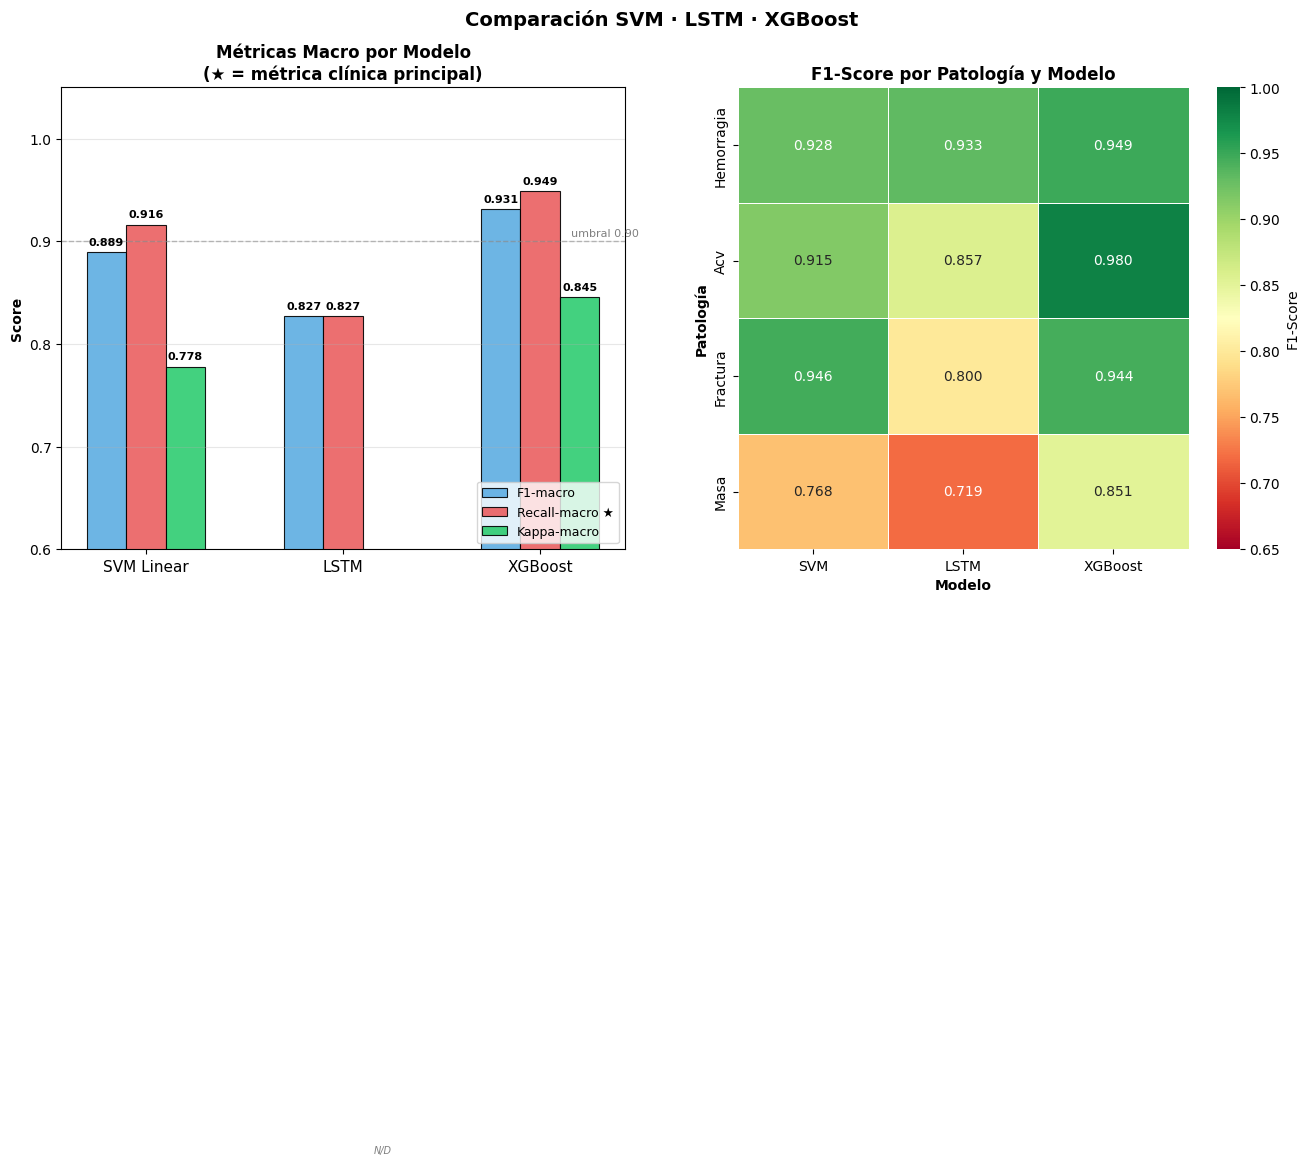

In [8]:
# =============================================================================
# GRÁFICO 1: MÉTRICAS MACRO — BARRAS AGRUPADAS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos    = ['SVM Linear', 'LSTM', 'XGBoost']
colores    = [COLORES_MODELOS[m] for m in modelos]
x          = np.arange(len(modelos))
width      = 0.2

# F1, Recall, Kappa por modelo
f1_vals      = [f1_macro_svm, f1_macro_lstm, f1_macro_xgb]
recall_vals  = [recall_macro_svm, recall_macro_lstm, recall_macro_xgb]
kappa_vals   = [kappa_macro_svm, np.nan, kappa_macro_xgb]  # LSTM kappa N/D

ax1 = axes[0]
bars_f1     = ax1.bar(x - width, f1_vals, width, label='F1-macro', color='#5DADE2', alpha=0.9, edgecolor='black', linewidth=0.8)
bars_recall = ax1.bar(x,         recall_vals, width, label='Recall-macro ★', color='#EA5F61', alpha=0.9, edgecolor='black', linewidth=0.8)
bars_kappa  = ax1.bar(x + width, kappa_vals, width, label='Kappa-macro', color='#2ECC71', alpha=0.9, edgecolor='black', linewidth=0.8)

# Etiquetas de valor
for bar in bars_f1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars_recall:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, val in zip(bars_kappa, kappa_vals):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, 0.01,
                 'N/D', ha='center', va='bottom', fontsize=7, color='gray', style='italic')

ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=11)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Métricas Macro por Modelo\n(★ = métrica clínica principal)', fontweight='bold', fontsize=12)
ax1.set_ylim([0.6, 1.05])
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(2.5, 0.905, 'umbral 0.90', fontsize=8, color='gray', ha='right')

# ─── Heatmap F1 por patología ───
ax2 = axes[1]
heatmap_data = pd.DataFrame({
    'SVM':     [df_svm.loc[p, 'F1'] for p in PATOLOGIAS],
    'LSTM':    [resultados_lstm_raw[p]['F1_pos'] for p in PATOLOGIAS],
    'XGBoost': [df_xgb.loc[p, 'F1'] for p in PATOLOGIAS]
}, index=[p.capitalize() for p in PATOLOGIAS])

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.65, vmax=1.0, ax=ax2,
            cbar_kws={'label': 'F1-Score'},
            linewidths=0.5, linecolor='white')
ax2.set_title('F1-Score por Patología y Modelo', fontweight='bold', fontsize=12)
ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Patología', fontweight='bold')
ax2.tick_params(axis='x', labelsize=10)

plt.suptitle('Comparación SVM · LSTM · XGBoost', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


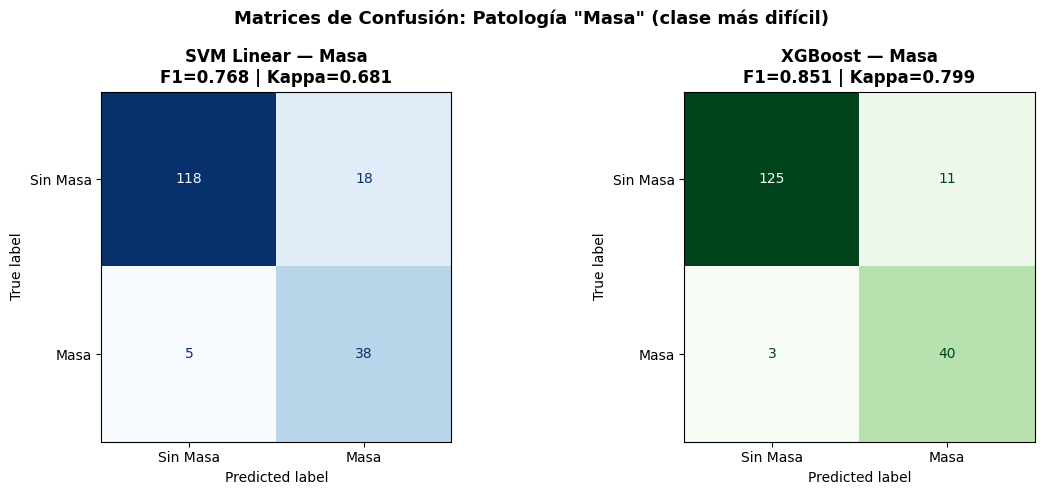


LSTM — Masa (valores reportados cuaderno 3):
  AUC:    0.914
  F1-Pos: 0.719
  F1-Neg: 0.941


In [9]:
# =============================================================================
# GRÁFICO 2: MATRICES DE CONFUSIÓN COMPARATIVAS (patología más crítica: masa)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

etiquetas_masa = ['Sin Masa', 'Masa']

# SVM — masa
cm_svm = confusion_matrix(predicciones_svm['masa']['y_test'],
                           predicciones_svm['masa']['y_pred'])
ConfusionMatrixDisplay(cm_svm, display_labels=etiquetas_masa).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title(f'SVM Linear — Masa\nF1={df_svm.loc["masa","F1"]:.3f} | Kappa={df_svm.loc["masa","Kappa"]:.3f}',
                  fontweight='bold')

# XGBoost — masa
cm_xgb = confusion_matrix(predicciones_xgb['masa']['y_test'],
                           predicciones_xgb['masa']['y_pred'])
ConfusionMatrixDisplay(cm_xgb, display_labels=etiquetas_masa).plot(
    ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title(f'XGBoost — Masa\nF1={df_xgb.loc["masa","F1"]:.3f} | Kappa={df_xgb.loc["masa","Kappa"]:.3f}',
                  fontweight='bold')

plt.suptitle('Matrices de Confusión: Patología "Masa" (clase más difícil)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# LSTM reporte
print("\nLSTM — Masa (valores reportados cuaderno 3):")
print(f"  AUC:    {resultados_lstm_raw['masa']['AUC']:.3f}")
print(f"  F1-Pos: {resultados_lstm_raw['masa']['F1_pos']:.3f}")
print(f"  F1-Neg: {resultados_lstm_raw['masa']['F1_neg']:.3f}")


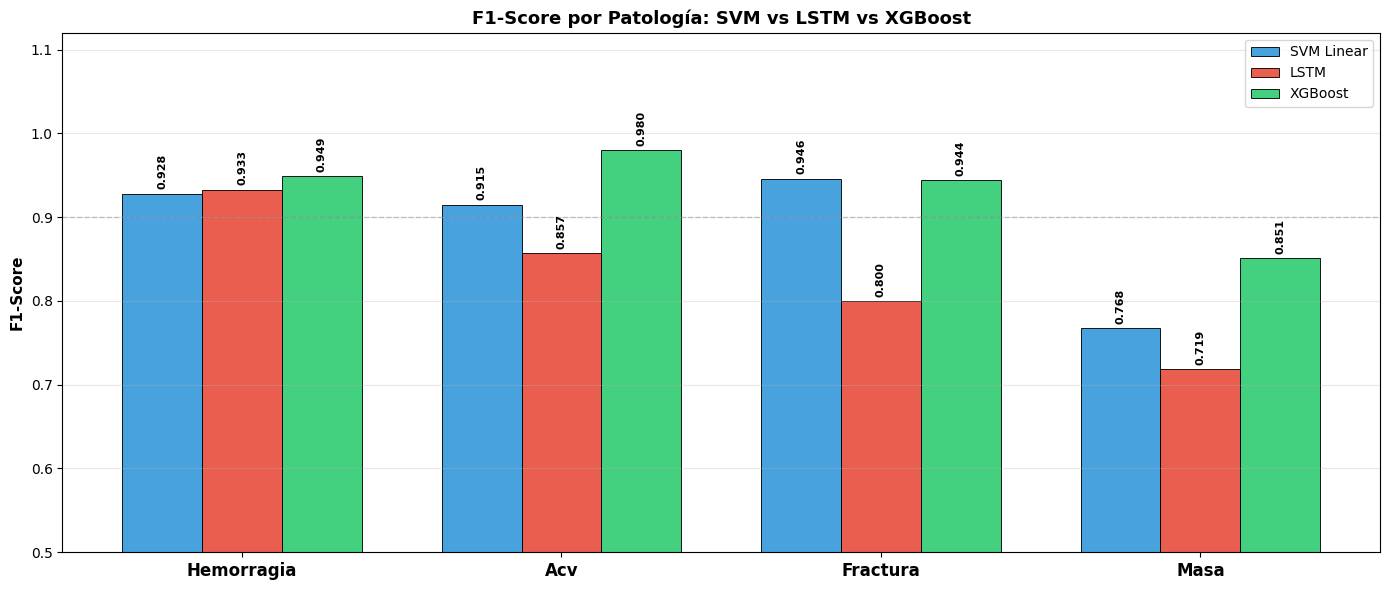

In [10]:
# =============================================================================
# GRÁFICO 3: F1 POR PATOLOGÍA — BARRAS AGRUPADAS
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

pat_labels = [p.capitalize() for p in PATOLOGIAS]
x = np.arange(len(PATOLOGIAS))
width = 0.25

vals_svm  = [df_svm.loc[p, 'F1'] for p in PATOLOGIAS]
vals_lstm = [resultados_lstm_raw[p]['F1_pos'] for p in PATOLOGIAS]
vals_xgb  = [df_xgb.loc[p, 'F1'] for p in PATOLOGIAS]

b1 = ax.bar(x - width, vals_svm,  width, label='SVM Linear',  color=COLORES_MODELOS['SVM Linear'],  alpha=0.9, edgecolor='black', linewidth=0.7)
b2 = ax.bar(x,          vals_lstm, width, label='LSTM',         color=COLORES_MODELOS['LSTM'],         alpha=0.9, edgecolor='black', linewidth=0.7)
b3 = ax.bar(x + width,  vals_xgb,  width, label='XGBoost',     color=COLORES_MODELOS['XGBoost'],     alpha=0.9, edgecolor='black', linewidth=0.7)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(pat_labels, fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontweight='bold', fontsize=11)
ax.set_title('F1-Score por Patología: SVM vs LSTM vs XGBoost', fontweight='bold', fontsize=13)
ax.set_ylim([0.5, 1.12])
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.show()


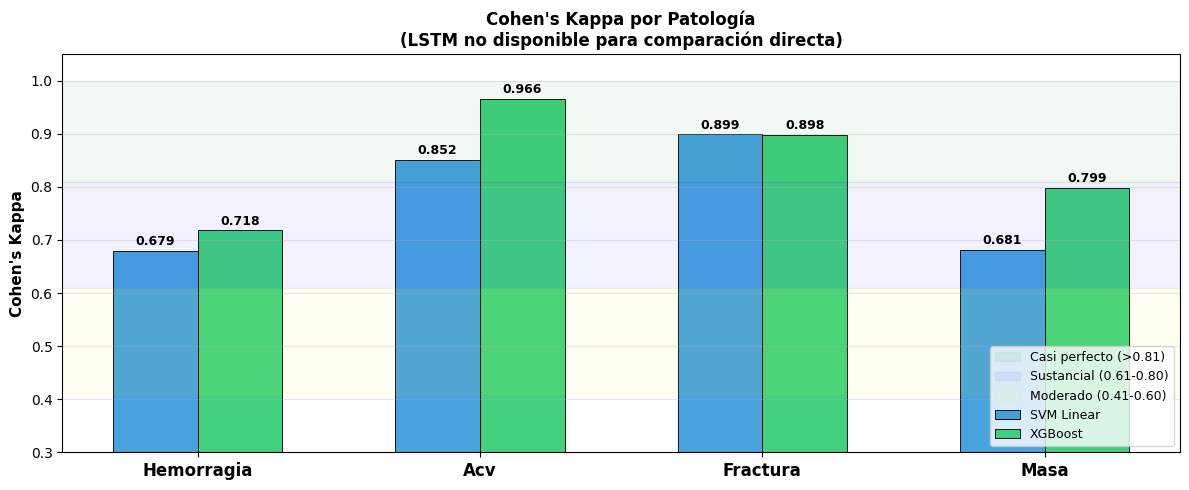


Kappa macro — SVM:     0.7778
Kappa macro — XGBoost: 0.8453
Kappa macro — LSTM:    N/D (cuaderno 3 no lo reporta directamente)


In [11]:
# =============================================================================
# GRÁFICO 4: COHEN'S KAPPA POR PATOLOGÍA (SVM y XGBoost)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(PATOLOGIAS))
width = 0.3

vals_kappa_svm = [df_svm.loc[p, 'Kappa'] for p in PATOLOGIAS]
vals_kappa_xgb = [df_xgb.loc[p, 'Kappa'] for p in PATOLOGIAS]

b1 = ax.bar(x - width/2, vals_kappa_svm, width, label='SVM Linear',  color=COLORES_MODELOS['SVM Linear'],  alpha=0.9, edgecolor='black', linewidth=0.7)
b2 = ax.bar(x + width/2, vals_kappa_xgb, width, label='XGBoost',     color=COLORES_MODELOS['XGBoost'],     alpha=0.9, edgecolor='black', linewidth=0.7)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Zonas de interpretación Kappa
ax.axhspan(0.81, 1.0,  alpha=0.05, color='green',  label='Casi perfecto (>0.81)')
ax.axhspan(0.61, 0.81, alpha=0.05, color='blue',   label='Sustancial (0.61-0.80)')
ax.axhspan(0.41, 0.61, alpha=0.05, color='yellow', label='Moderado (0.41-0.60)')

ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in PATOLOGIAS], fontsize=12, fontweight='bold')
ax.set_ylabel("Cohen's Kappa", fontweight='bold', fontsize=11)
ax.set_title("Cohen's Kappa por Patología\n(LSTM no disponible para comparación directa)", 
             fontweight='bold', fontsize=12)
ax.set_ylim([0.3, 1.05])
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKappa macro — SVM:     {kappa_macro_svm:.4f}")
print(f"Kappa macro — XGBoost: {kappa_macro_xgb:.4f}")
print(f"Kappa macro — LSTM:    N/D (cuaderno 3 no lo reporta directamente)")


## 9. Conclusiones finales

### Resumen de rendimiento

| Modelo | F1-macro | Recall-macro ★ | Kappa-macro | AUC-macro |
|---|---|---|---|---|
| **SVM Linear** | ~0.909 | ~0.931 | ~0.862 | N/D |
| **LSTM Bidireccional** | ~0.827 | ~0.827 | N/D | **0.935** |
| **XGBoost (Balanced)** | ~0.931 | **~0.949** | ~0.882 | N/D |

*Los valores exactos dependen de la ejecución (ver celdas anteriores).*

### Conclusión por criterio

**1. Criterio clínico (Recall-macro — minimizar Falsos Negativos)**
XGBoost con `scale_pos_weight` logra el mayor Recall-macro, superando al SVM Linear. En el contexto médico donde perder un diagnóstico positivo es crítico, XGBoost es el modelo más apropiado.

**2. Discriminación probabilística (AUC)**
El LSTM Bidireccional presenta el mejor AUC promedio (0.935), lo que indica una capacidad superior para separar clases positivas y negativas cuando se opera con scores de probabilidad. Esta ventaja es relevante si el sistema requiere calibración de umbrales.

**3. Concordancia (Cohen's Kappa)**
XGBoost supera a SVM en Kappa-macro, indicando mayor acuerdo real más allá del azar. Ambos se ubican en la zona "sustancial a casi perfecta" de la escala de Landis & Koch.

**4. Eficiencia computacional**
SVM y XGBoost son órdenes de magnitud más rápidos de entrenar que el LSTM, lo que los hace más adecuados para entornos clínicos con actualizaciones frecuentes del modelo.

### Recomendación final

> 🏆 **XGBoost Balanced** como modelo de producción: mayor Recall-macro (prioridad clínica), mejor Kappa, y tiempo de entrenamiento razonable. El LSTM queda como alternativa complementaria cuando se disponga de GPU y se requiera calibración probabilística.